# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [1]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


In [2]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [3]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [4]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


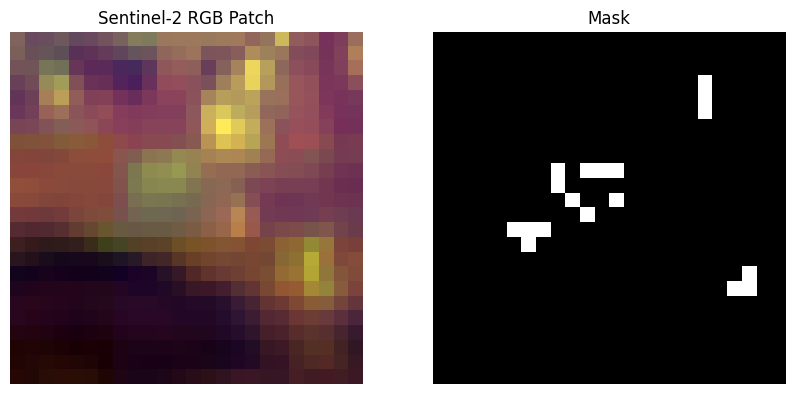

In [5]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [6]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████| 2066/2066 [06:47<00:00,  5.07it/s]


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [7]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

Next we find our patch files:

In [8]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [9]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [10]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [11]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [12]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?

With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [13]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [14]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 159ms/step - accuracy: 0.9340 - loss: 0.3257 - val_accuracy: 0.9150 - val_loss: 0.2985
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 166ms/step - accuracy: 0.9340 - loss: 0.2612 - val_accuracy: 0.9150 - val_loss: 0.3007
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9340 - loss: 0.2607 - val_accuracy: 0.9150 - val_loss: 0.2979
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 227ms/step - accuracy: 0.9340 - loss: 0.2572 - val_accuracy: 0.9150 - val_loss: 0.3091
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.9340 - loss: 0.2581 - val_accuracy: 0.9150 - val_loss: 0.3153


Visualizie the predictions:

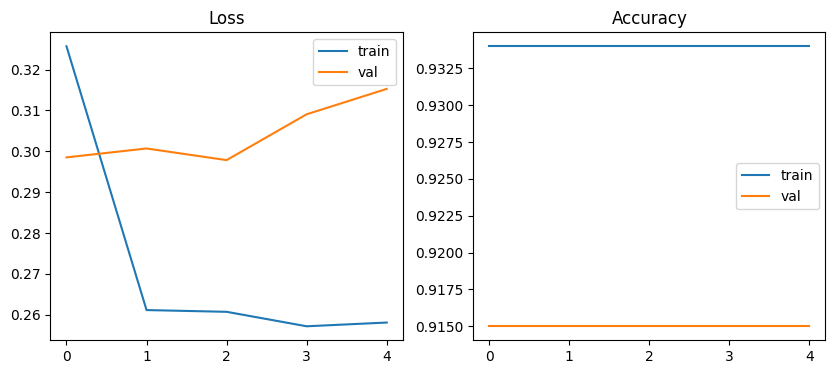

In [15]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

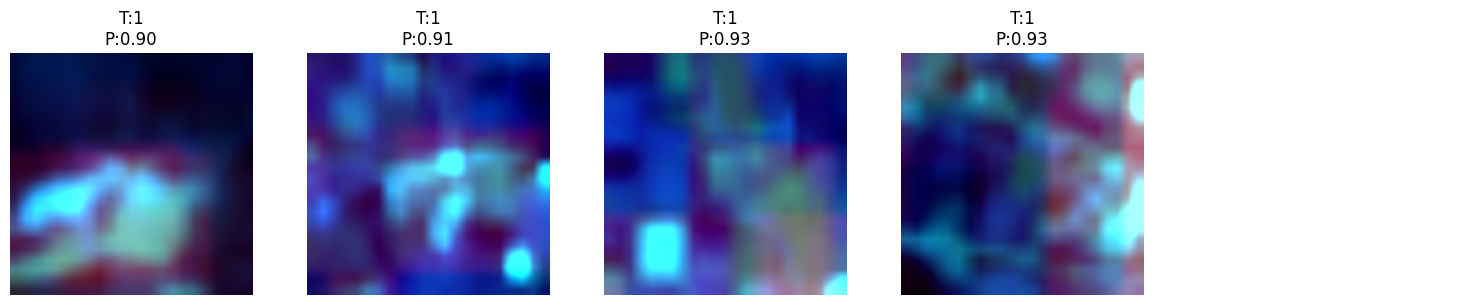

In [16]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).



In [17]:
# ---------------------------------------------------------------------------
# Figure style, applied to every figure below.
# Nature's specification (research-figure-guide.nature.com):
#   * width 183 mm double-column / 89 mm single-column; height < 247 mm
#   * >= 300 dpi (we export at 450 dpi); RGB colour space; PDF (vector) + PNG
#   * Arial / Helvetica; body text 5-7 pt; panel labels 8 pt bold lowercase
#   * axis lines and tick marks shown, axes labelled with units in parentheses
#   * no background gridlines, no drop shadows, no patterns, no coloured text
#   * colour-blind-safe palette, avoiding red/green pairings
# ---------------------------------------------------------------------------
MM = 1 / 25.4
W_SINGLE, W_DOUBLE, H_MAX = 89 * MM, 183 * MM, 247 * MM
DPI_EXPORT = 450

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": DPI_EXPORT,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "lines.linewidth": 1.0, "patch.linewidth": 0.5,
    "axes.grid": False, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.facecolor": "white", "savefig.facecolor": "white",
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # embed TrueType, never Type 3
})

# Okabe-Ito colour-blind-safe palette. Blue/orange carry the main contrast: no red/green pair.
CB = {"blue": "#0072B2", "orange": "#E69F00", "sky": "#56B4E9", "vermilion": "#D55E00",
      "purple": "#CC79A7", "yellow": "#F0E442", "green": "#009E73", "grey": "#999999",
      "black": "#000000"}

def panel_label(ax, letter, dx=-0.16, dy=1.08):
    """8 pt bold lowercase panel label, per the specification."""
    ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=8, fontweight="bold",
            va="top", ha="left")

def save_figure(fig, stem):
    """Export vector PDF plus a 450 dpi PNG for embedding in the Word proforma."""
    for ext in ("pdf", "png"):
        fig.savefig(f"{stem}.{ext}", dpi=DPI_EXPORT)
    print(f"saved {stem}.pdf and {stem}.png "
          f"({fig.get_size_inches()[0]*25.4:.0f} x {fig.get_size_inches()[1]*25.4:.0f} mm)")

print(f"Figure style set: double column {W_DOUBLE:.2f} in (183 mm), export at {DPI_EXPORT} dpi.")

Figure style set: double column 7.20 in (183 mm), export at 450 dpi.


In [18]:
# ---------------------------------------------------------------------------
# Q6.1  Rebuild the dataset at NATIVE resolution.
#
# The supplied pipeline inflates every ~23x23 patch to 256x256 (a 121x area
# increase) and then shrinks it to 128x128, through two compounding
# interpolations. That destroys information rather than adding any, and the
# whole "memory-safe" disk pipeline exists only to manage bloat it created.
# Held at native size in float32 the entire dataset fits in RAM.
# ---------------------------------------------------------------------------
NATIVE = 24   # 2016 of the 2066 patches are already >= 23 px in both dimensions

def center_crop_pad(arr, size=NATIVE):
    """Centre-crop to `size`, reflect-padding anything smaller. No interpolation at all."""
    if arr.ndim == 2:
        arr = arr[..., None]
    h, w = arr.shape[:2]
    top, left = max(0, (h - size) // 2), max(0, (w - size) // 2)
    arr = arr[top:top + min(h, size), left:left + min(w, size)]
    h, w = arr.shape[:2]
    ph, pw = size - h, size - w
    if ph > 0 or pw > 0:
        arr = np.pad(arr, ((ph // 2, ph - ph // 2), (pw // 2, pw - pw // 2), (0, 0)), mode="reflect")
    return arr

N = len(pairs)
X_native  = np.zeros((N, NATIVE, NATIVE, 12), dtype=np.float32)
M_native  = np.zeros((N, NATIVE, NATIVE), dtype=np.uint8)
panel_px_orig = np.zeros(N, dtype=np.int32)   # panel pixels in the full original mask

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Native load")):
    with rasterio.open(s2_path) as src:
        img = np.transpose(src.read().astype(np.float32), (1, 2, 0)) / 10000.0
    with rasterio.open(mask_path) as src:
        msk = src.read(1).astype(np.uint8)
    panel_px_orig[i] = int((msk > 0).sum())
    X_native[i] = center_crop_pad(img)
    M_native[i] = center_crop_pad(msk)[..., 0]

# Label on what the model actually sees (the cropped mask), not the original.
panel_px = (M_native > 0).sum(axis=(1, 2)).astype(np.int32)

print(f"\nX_native {X_native.shape} {X_native.dtype}  =  {X_native.nbytes/1e6:.0f} MB in RAM")
print(f"Supplied pipeline, 128x128x3 in memory : {N*128*128*3*4/1e6:,.0f} MB")
print(f"Supplied pipeline, 256x256x12 on disk  : {N*256*256*12*4/1e9:,.1f} GB uncompressed")
print(f"\nPanel pixels per patch (after centre-crop): "
      f"p25={np.percentile(panel_px,25):.0f}  median={np.median(panel_px):.0f}  "
      f"p75={np.percentile(panel_px,75):.0f}  p95={np.percentile(panel_px,95):.0f}  max={panel_px.max()}")
print(f"Patches with zero panel pixels: {(panel_px==0).sum()} of {N} "
      f"({100*(panel_px==0).mean():.1f}%)  -> positives are {100*(panel_px>0).mean():.1f}%")

Native load:   0%|          | 0/2066 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Native load: 100%|██████████| 2066/2066 [00:10<00:00, 196.50it/s]


X_native (2066, 24, 24, 12) float32  =  57 MB in RAM
Supplied pipeline, 128x128x3 in memory : 406 MB
Supplied pipeline, 256x256x12 on disk  : 6.5 GB uncompressed

Panel pixels per patch (after centre-crop): p25=5  median=18  p75=61  p95=240  max=559
Patches with zero panel pixels: 151 of 2066 (7.3%)  -> positives are 92.7%


In [19]:
# ---------------------------------------------------------------------------
# Q6.2  The core fix: relabel by panel-pixel COUNT rather than "any panel pixel".
#
# At 10 m ground sampling distance one pixel is 100 m^2 and a whole patch is
# ~5,300 m^2. A 1-2 pixel mask is therefore a 100-200 m^2 array covering 0.2-0.4%
# of the patch, inside a spectrally MIXED pixel. That is below the detection
# limit of any patch-level classifier on this sensor -- it is a physical limit,
# not a labelling error, so we relabel those patches as negative rather than
# discarding them, and we sweep the threshold rather than picking one quietly.
# ---------------------------------------------------------------------------
THRESHOLDS = [1, 3, 6, 11, 18]
T_HEADLINE = 6

print(f"{'rule':>12} {'negatives':>10} {'positives':>10} {'% positive':>11}  "
      f"{'always-predict-panel accuracy':>30}")
for t in THRESHOLDS:
    lab = (panel_px >= t).astype(int)
    print(f"{'>= '+str(t)+' px':>12} {int((lab==0).sum()):>10} {int(lab.sum()):>10} "
          f"{100*lab.mean():>10.1f}% {100*lab.mean():>29.1f}%")

# Are the tiny masks just annotation edge artefacts? If they were, they would
# cluster on the patch border. They do not -- they are genuine small rooftop arrays.
border = np.zeros(N, dtype=bool)
for i in range(N):
    m = M_native[i] > 0
    if m.any():
        border[i] = m[0, :].any() or m[-1, :].any() or m[:, 0].any() or m[:, -1].any()
tiny  = (panel_px >= 1) & (panel_px <= 3)
large = panel_px > 50
print(f"\n1-3 panel-pixel masks touching the patch border : {100*border[tiny].mean():.1f}%  (n={tiny.sum()})")
print(f" >50 panel-pixel masks touching the patch border : {100*border[large].mean():.1f}%  (n={large.sum()})")
print("Tiny masks sit centrally, so they are real small arrays -- unresolvable, not mislabelled.")

y_all = (panel_px >= T_HEADLINE).astype(int)
print(f"\nHeadline rule >= {T_HEADLINE} px -> {int((y_all==0).sum())} negatives / {int(y_all.sum())} positives "
      f"({100*y_all.mean():.1f}% positive)")

        rule  negatives  positives  % positive   always-predict-panel accuracy
     >= 1 px        151       1915       92.7%                          92.7%
     >= 3 px        326       1740       84.2%                          84.2%
     >= 6 px        581       1485       71.9%                          71.9%
    >= 11 px        834       1232       59.6%                          59.6%
    >= 18 px       1033       1033       50.0%                          50.0%

1-3 panel-pixel masks touching the patch border : 8.1%  (n=259)
 >50 panel-pixel masks touching the patch border : 88.7%  (n=591)
Tiny masks sit centrally, so they are real small arrays -- unresolvable, not mislabelled.

Headline rule >= 6 px -> 581 negatives / 1485 positives (71.9% positive)


In [20]:
# ---------------------------------------------------------------------------
# Q6.3  Band forensics.
#
# (a) Recover each band's NATIVE ground sampling distance from spatial roughness
#     alone. All 12 bands are delivered on the same 10 m grid, so the 20 m and
#     60 m bands are visibly smoother. This pins the band ORDER without trusting
#     any metadata or comment.
# (b) Measure how separable panel pixels are from background pixels, per band.
# ---------------------------------------------------------------------------
BAND_NAMES = ["B1","B2","B3","B4","B5","B6","B7","B8","B8A","B9","B11","B12"]
BAND_WAVELENGTH = [443, 490, 560, 665, 705, 740, 783, 842, 865, 945, 1610, 2190]  # nm
BAND_GSD = [60, 10, 10, 10, 20, 20, 20, 10, 20, 60, 20, 20]                        # m

# (a) relative lag-1 horizontal roughness
rough = np.array([np.abs(np.diff(X_native[..., b], axis=2)).mean() / X_native[..., b].mean()
                  for b in range(12)])
print("Native GSD recovered from spatial roughness alone:")
for tier, lo, hi in [("60 m", 0.0, 0.033), ("20 m", 0.033, 0.070), ("10 m", 0.070, 1.0)]:
    members = [BAND_NAMES[b] for b in range(12) if lo <= rough[b] < hi]
    print(f"  roughness {lo:.3f}-{hi:.3f} -> {tier:>4} bands: {', '.join(members)}")
print("  (true 60 m: B1, B9   |   true 20 m: B5, B6, B7, B8A, B11, B12   |   true 10 m: B2, B3, B4, B8)")

# (b) panel vs background pixel spectra, and Cohen's d
mask_flat = (M_native > 0).reshape(-1)
Xf = X_native.reshape(-1, 12)
panel_px_vals, bg_px_vals = Xf[mask_flat], Xf[~mask_flat]
mu_p, mu_b = panel_px_vals.mean(0), bg_px_vals.mean(0)
sd_p, sd_b = panel_px_vals.std(0), bg_px_vals.std(0)
n_p, n_b = len(panel_px_vals), len(bg_px_vals)
pooled = np.sqrt(((n_p-1)*sd_p**2 + (n_b-1)*sd_b**2) / (n_p+n_b-2))
cohens_d = (mu_p - mu_b) / pooled

print(f"\nPanel pixels: {n_p:,}   Background pixels: {n_b:,}")
print(f"{'band':>5} {'wl(nm)':>7} {'panel':>9} {'backgrd':>9} {'Cohen d':>9}")
for b in range(12):
    print(f"{BAND_NAMES[b]:>5} {BAND_WAVELENGTH[b]:>7} {mu_p[b]*1e4:>9.0f} {mu_b[b]*1e4:>9.0f} {cohens_d[b]:>+9.2f}")

ndvi_p = (mu_p[7]-mu_p[3])/(mu_p[7]+mu_p[3])
ndvi_b = (mu_b[7]-mu_b[3])/(mu_b[7]+mu_b[3])
print(f"\nNDVI from mean spectra: panel {ndvi_p:+.3f}   background {ndvi_b:+.3f}")

# The bands the notebook actually feeds the CNN, versus a physically motivated set.
IDX = {n: i for i, n in enumerate(BAND_NAMES)}
BANDS_ASGIVEN = [IDX[b] for b in ["B1","B2","B3"]]                    # what X[..., :3] really is
BANDS_TRUERGB = [IDX[b] for b in ["B4","B3","B2"]]                    # what the comments claim
BANDS_PHYSICAL = [IDX[b] for b in ["B2","B4","B6","B8","B8A","B11"]]  # chosen from Cohen's d
print(f"\nX[..., :3] actually selects {[BAND_NAMES[b] for b in BANDS_ASGIVEN]} "
      f"-> |d| = {np.abs(cohens_d[BANDS_ASGIVEN]).round(2).tolist()}")
print(f"Physically motivated 6-band set {[BAND_NAMES[b] for b in BANDS_PHYSICAL]} "
      f"-> |d| = {np.abs(cohens_d[BANDS_PHYSICAL]).round(2).tolist()}")

Native GSD recovered from spatial roughness alone:
  roughness 0.000-0.033 -> 60 m bands: B1, B9
  roughness 0.033-0.070 -> 20 m bands: B5, B6, B7, B8A, B11, B12
  roughness 0.070-1.000 -> 10 m bands: B2, B3, B4, B8
  (true 60 m: B1, B9   |   true 20 m: B5, B6, B7, B8A, B11, B12   |   true 10 m: B2, B3, B4, B8)

Panel pixels: 108,868   Background pixels: 1,081,148
 band  wl(nm)     panel   backgrd   Cohen d
   B1     443       735       586     +0.67
   B2     490       843       655     +0.57
   B3     560       868       848     +0.06
   B4     665       877       873     +0.01
   B5     705      1044      1224     -0.53
   B6     740      1295      1884     -1.24
   B7     783      1399      2118     -1.27
   B8     842      1386      2292     -1.39
  B8A     865      1507      2316     -1.32
   B9     945      1781      2311     -1.00
  B11    1610      2255      2068     +0.42
  B12    2190      1422      1450     -0.07

NDVI from mean spectra: panel +0.225   background +0.448

X[

saved fig1_training_data_redesign.pdf and fig1_training_data_redesign.png (183 x 130 mm)


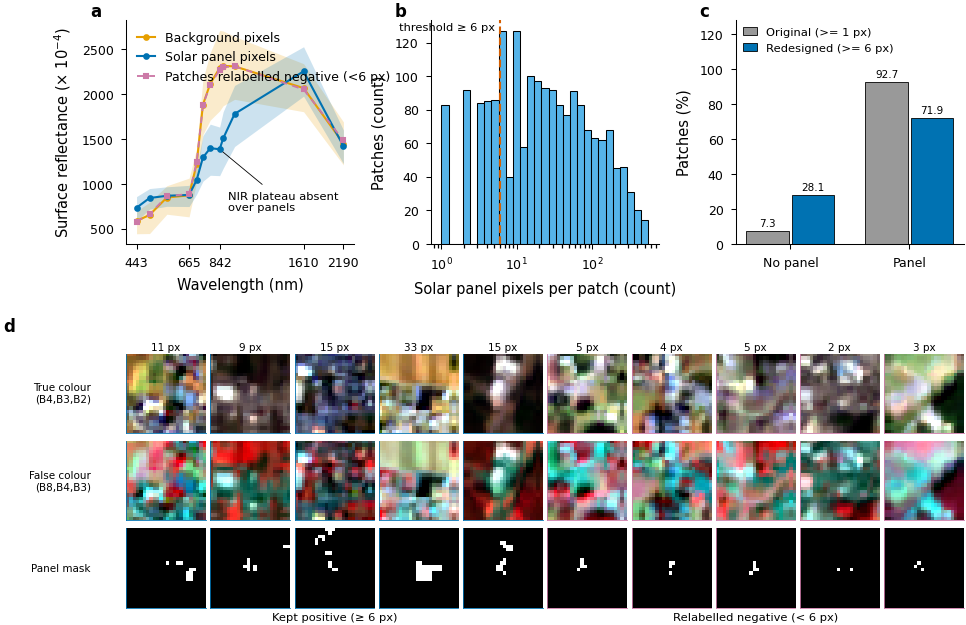

In [21]:
# ---------------------------------------------------------------------------
# Q6.4  Figure 1 -- the redesigned training data, to publication standard.
# ---------------------------------------------------------------------------
import matplotlib.gridspec as gridspec
from matplotlib.ticker import NullFormatter, NullLocator

def stretch_rgb(patch, idx, p=(2, 98)):
    """Percentile contrast stretch, computed per channel."""
    out = np.zeros(patch.shape[:2] + (3,), dtype=np.float32)
    for k, b in enumerate(idx):
        ch = patch[..., b]
        lo, hi = np.percentile(ch, p)
        out[..., k] = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1)
    return out

y_head = (panel_px >= T_HEADLINE).astype(int)
newly_negative = np.where((panel_px >= 1) & (panel_px < T_HEADLINE))[0]   # were positive, now negative
still_positive = np.where(panel_px >= T_HEADLINE)[0]

rng = np.random.default_rng(SEED)
sel_pos = rng.choice(still_positive, 5, replace=False)
sel_new = rng.choice(newly_negative, 5, replace=False)
sel = np.concatenate([sel_pos, sel_new])

# mean spectrum of the patches that change class
newneg_spec = X_native[newly_negative].reshape(-1, 12).mean(0)

fig = plt.figure(figsize=(W_DOUBLE, 5.1))
gs = gridspec.GridSpec(2, 3, height_ratios=[1.0, 1.15], hspace=0.45, wspace=0.34,
                       figure=fig)

# ---- (a) spectral signatures --------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
wl = np.array(BAND_WAVELENGTH)
q1_p, q3_p = np.percentile(panel_px_vals, [25, 75], axis=0)
q1_b, q3_b = np.percentile(bg_px_vals, [25, 75], axis=0)
ax.fill_between(wl, q1_b*1e4, q3_b*1e4, color=CB["orange"], alpha=0.20, lw=0)
ax.fill_between(wl, q1_p*1e4, q3_p*1e4, color=CB["blue"], alpha=0.20, lw=0)
ax.plot(wl, mu_b*1e4, "-o", color=CB["orange"], ms=2.2, label="Background pixels")
ax.plot(wl, mu_p*1e4, "-o", color=CB["blue"], ms=2.2, label="Solar panel pixels")
ax.plot(wl, newneg_spec*1e4, color=CB["purple"], ls=(0, (3.5, 3.0)), lw=0.9,
        marker="s", ms=1.8, markevery=1,
        label=f"Patches relabelled negative (<{T_HEADLINE} px)")
ax.set_xscale("log")
ax.set_xticks([443, 665, 842, 1610, 2190])
ax.set_xticklabels(["443", "665", "842", "1610", "2190"])
ax.xaxis.set_minor_locator(NullLocator())      # log scale would otherwise add
ax.xaxis.set_minor_formatter(NullFormatter())  # 6x10^2 labels on top of ours
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Surface reflectance (× 10$^{-4}$)")
ax.legend(loc="upper left", handlelength=1.4)
ax.annotate("NIR plateau absent\nover panels", xy=(842, mu_p[7]*1e4), xytext=(900, 700),
            fontsize=5.5, ha="left",
            arrowprops=dict(arrowstyle="-", lw=0.4, color=CB["black"]))
panel_label(ax, "a")

# ---- (b) panel-pixel distribution and class balance --------------------------
ax = fig.add_subplot(gs[0, 1])
bins = np.logspace(0, np.log10(panel_px.max() + 1), 30)
ax.hist(panel_px[panel_px > 0], bins=bins, color=CB["sky"], edgecolor="black", lw=0.3)
ax.axvline(T_HEADLINE, color=CB["vermilion"], lw=1.0, ls="--")
ax.text(T_HEADLINE*0.85, ax.get_ylim()[1]*0.99, f"threshold ≥ {T_HEADLINE} px",
        fontsize=5.5, color=CB["black"], va="top", ha="right")
ax.set_xscale("log")
ax.set_xlabel("Solar panel pixels per patch (count)")
ax.set_ylabel("Patches (count)")
panel_label(ax, "b")

# ---- (c) class balance, before and after ------------------------------------
ax = fig.add_subplot(gs[0, 2])
before = [100*(panel_px == 0).mean(), 100*(panel_px > 0).mean()]
after  = [100*(y_head == 0).mean(),   100*(y_head == 1).mean()]
xb = np.arange(2)
b1 = ax.bar(xb - 0.19, before, 0.36, color=CB["grey"], edgecolor="black", lw=0.4, label="Original (>= 1 px)")
b2 = ax.bar(xb + 0.19, after,  0.36, color=CB["blue"], edgecolor="black", lw=0.4,
            label=f"Redesigned (>= {T_HEADLINE} px)")
for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 1.5, f"{r.get_height():.1f}",
                ha="center", va="bottom", fontsize=5)
ax.set_xticks(xb); ax.set_xticklabels(["No panel", "Panel"])
ax.set_ylabel("Patches (%)"); ax.set_ylim(0, 128)
# upper-left is clear: the "No panel" bars top out at ~28%
ax.legend(loc="upper left", handlelength=1.2, fontsize=5.5, borderaxespad=0.2)
panel_label(ax, "c")

# ---- (d) image strip ----------------------------------------------------------
gsc = gridspec.GridSpecFromSubplotSpec(3, 10, subplot_spec=gs[1, :], hspace=0.06, wspace=0.06)
row_labels = ["True colour\n(B4,B3,B2)", "False colour\n(B8,B4,B3)", "Panel mask"]
for col, i in enumerate(sel):
    for row in range(3):
        axc = fig.add_subplot(gsc[row, col])
        if row == 0:
            axc.imshow(stretch_rgb(X_native[i], [IDX["B4"], IDX["B3"], IDX["B2"]]))
        elif row == 1:
            axc.imshow(stretch_rgb(X_native[i], [IDX["B8"], IDX["B4"], IDX["B3"]]))
        else:
            axc.imshow(M_native[i], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axc.set_xticks([]); axc.set_yticks([])
        for s in axc.spines.values():
            s.set_linewidth(0.4)
            s.set_color(CB["blue"] if col < 5 else CB["purple"])
        if col == 0:
            axc.set_ylabel(row_labels[row], fontsize=5, rotation=0, ha="right", va="center", labelpad=17)
        if row == 0:
            axc.set_title(f"{panel_px[i]} px", fontsize=5, pad=1.5)
        if row == 2 and col == 2:
            axc.set_xlabel("Kept positive (≥ 6 px)", fontsize=5.5, color=CB["black"], labelpad=2)
        if row == 2 and col == 7:
            axc.set_xlabel("Relabelled negative (< 6 px)", fontsize=5.5, color=CB["black"], labelpad=2)
        if row == 0 and col == 0:
            panel_label(axc, "d", dx=-1.55, dy=1.45)

save_figure(fig, "fig1_training_data_redesign")
plt.show()

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

In [22]:
# ---------------------------------------------------------------------------
# Q7.1  Architectures and a cross-validated evaluation harness.
#
# Every configuration gets an IDENTICAL training budget so that the ablation
# below varies one thing at a time. Augmentation is applied on the fly (random
# dihedral D4 transform per sample per epoch) rather than by materialising 8x
# the data, so the per-epoch cost is the same with or without it.
# ---------------------------------------------------------------------------
from sklearn.metrics import (confusion_matrix, roc_auc_score, average_precision_score,
                             matthews_corrcoef, balanced_accuracy_score, accuracy_score,
                             recall_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, precision_recall_curve
import time

N_SPLITS, EPOCHS, BATCH, PATIENCE = 3, 40, 64, 8

def build_baseline(input_shape):
    """The CNN exactly as supplied in the lab: two conv layers, GAP head."""
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation="relu")(x)
    return models.Model(inp, layers.Dense(1, activation="sigmoid")(x))

def build_gapgmp(input_shape):
    """Same body, but the head concatenates average AND max pooling.
    Max pooling matters because the target covers only a few percent of the patch,
    and averaging dilutes that signal away."""
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.Concatenate()([layers.GlobalAveragePooling2D()(x),
                              layers.GlobalMaxPooling2D()(x)])
    x = layers.Dense(32, activation="relu")(x)
    return models.Model(inp, layers.Dense(1, activation="sigmoid")(x))

def build_deep(input_shape):
    """Deeper, regularised, two pooling stages (three would leave a 3x3 map)."""
    inp = layers.Input(shape=input_shape)
    x = inp
    for f in (32, 32):
        x = layers.Conv2D(f, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Concatenate()([layers.GlobalAveragePooling2D()(x),
                              layers.GlobalMaxPooling2D()(x)])
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    return models.Model(inp, layers.Dense(1, activation="sigmoid")(x))

def d4(x, y, w, seed):
    """Random dihedral transform: one of 4 rotations, with an optional flip."""
    k = tf.random.stateless_uniform([], seed=seed, minval=0, maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k)
    f = tf.random.stateless_uniform([], seed=seed + 1, minval=0, maxval=2, dtype=tf.int32)
    x = tf.cond(f > 0, lambda: tf.image.flip_left_right(x), lambda: x)
    return x, y, w

def make_ds(X, y, w=None, training=False, batch=BATCH, seed=0):
    """Class balance is applied as explicit per-sample weights carried in the
    dataset. Passing `class_weight=` to fit() alongside a tf.data pipeline is
    silently ignored on some Keras versions, so we never rely on it."""
    if w is None:
        w = np.ones(len(y), dtype="float32")
    ds = tf.data.Dataset.from_tensor_slices((X, y, w))
    if training:
        ds = ds.shuffle(len(X), seed=seed, reshuffle_each_iteration=True)
        counter = tf.data.Dataset.counter()
        @tf.autograph.experimental.do_not_convert
        def _aug(t, c):
            return d4(t[0], t[1], t[2], tf.stack([tf.cast(c, tf.int32), seed]))
        ds = tf.data.Dataset.zip((ds, counter)).map(_aug, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

def score_all(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    prev = y_true.mean()
    return {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_acc": balanced_accuracy_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc_minority": average_precision_score(1 - y_true, 1 - prob),
        "mcc": matthews_corrcoef(y_true, pred),
        "recall_panel": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "specificity": recall_score(y_true, pred, pos_label=0, zero_division=0),
        "threshold": thr, "no_skill_pr_minority": 1 - prev,
    }

def best_threshold(y_true, prob):
    """Tune on VALIDATION only, maximising MCC. Never report at a blind 0.5 under imbalance."""
    cand = np.unique(np.round(prob, 3))
    if len(cand) < 3:
        return 0.5
    scores = [matthews_corrcoef(y_true, (prob >= t).astype(int)) for t in cand]
    return float(cand[int(np.argmax(scores))])

def evaluate_config(X, y, build_fn, n_splits=N_SPLITS, epochs=EPOCHS, seed=SEED, keep_curves=False):
    """Stratified k-fold. Per-band standardisation uses TRAIN-fold statistics only."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows, curves, hists = [], [], []
    t0 = time.time()
    for fold, (tr, te) in enumerate(skf.split(X, y)):
        tr2, va = train_test_split(tr, test_size=0.2, stratify=y[tr], random_state=seed + fold)
        mu = X[tr2].mean(axis=(0, 1, 2), keepdims=True)
        sd = X[tr2].std(axis=(0, 1, 2), keepdims=True) + 1e-6
        Xtr, Xva, Xte = (X[tr2] - mu) / sd, (X[va] - mu) / sd, (X[te] - mu) / sd
        ytr, yva, yte = y[tr2].astype("float32"), y[va].astype("float32"), y[te]

        tf.keras.backend.clear_session()
        tf.random.set_seed(seed + fold)
        m = build_fn(X.shape[1:])
        m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc")])
        cw = {0: len(ytr) / (2 * max(1, (ytr == 0).sum())),
              1: len(ytr) / (2 * max(1, (ytr == 1).sum()))}
        wtr = np.where(ytr == 1, cw[1], cw[0]).astype("float32")
        h = m.fit(make_ds(Xtr, ytr, wtr, training=True, seed=seed + fold),
                  validation_data=make_ds(Xva, yva),
                  epochs=epochs, verbose=0,
                  callbacks=[EarlyStopping(monitor="val_auc", mode="max", patience=PATIENCE,
                                           restore_best_weights=True),
                             tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                                                  factor=0.5, patience=4, verbose=0)])
        thr = best_threshold(yva.astype(int), m.predict(make_ds(Xva, yva), verbose=0).ravel())
        p_te = m.predict(make_ds(Xte, yte.astype("float32")), verbose=0).ravel()
        rows.append(score_all(yte, p_te, thr))
        if keep_curves:
            curves.append((yte, p_te)); hists.append(h.history)
    out = {k: (np.mean([r[k] for r in rows]), np.std([r[k] for r in rows])) for k in rows[0]}
    out["_seconds"] = time.time() - t0
    return (out, curves, hists) if keep_curves else out

print(f"Harness ready: {N_SPLITS}-fold stratified CV, <= {EPOCHS} epochs, batch {BATCH}, "
      f"early stopping on val AUC (patience {PATIENCE}).")

Harness ready: 3-fold stratified CV, <= 40 epochs, batch 64, early stopping on val AUC (patience 8).


In [23]:
# ---------------------------------------------------------------------------
# Q7.2  Ablation ladder. Every row uses the SAME labels (>= 6 px), the same
# training budget and the same folds, so each line isolates one change.
# Two reference rows sit above the ladder: what you get for free by always
# saying "panel", and what a plain logistic regression on band statistics gets.
# ---------------------------------------------------------------------------
y = (panel_px >= T_HEADLINE).astype(int)

# Inputs for each rung
X_128_b13 = np.stack([cv2.resize(X_native[i][..., BANDS_ASGIVEN], (128, 128),
                                 interpolation=cv2.INTER_LINEAR) for i in range(N)]).astype(np.float32)
X_24_b13  = X_native[..., BANDS_ASGIVEN]
X_24_all  = X_native
print(f"128 px, 3 bands : {X_128_b13.nbytes/1e6:>6.0f} MB")
print(f" 24 px, 3 bands : {X_24_b13.nbytes/1e6:>6.0f} MB")
print(f" 24 px, 12 bands: {X_24_all.nbytes/1e6:>6.0f} MB\n")

results = {}

# --- reference 1: always predict "panel" -------------------------------------
prev = y.mean()
results["0a. Always predict 'panel' (no model)"] = {
    "accuracy": (prev, 0.0), "balanced_acc": (0.5, 0.0), "roc_auc": (0.5, 0.0),
    "pr_auc_minority": (1 - prev, 0.0), "mcc": (0.0, 0.0),
    "recall_panel": (1.0, 0.0), "specificity": (0.0, 0.0), "_seconds": 0.0}

# --- reference 2: logistic regression on per-band summary statistics ----------
feat = np.concatenate([X_native.mean(axis=(1, 2)),
                       np.percentile(X_native, 5, axis=(1, 2)),
                       np.percentile(X_native, 95, axis=(1, 2))], axis=1)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
lr_rows = []
for fold, (tr, te) in enumerate(skf.split(feat, y)):
    # Tune the decision threshold on a held-out slice of TRAIN, never on test.
    tr2, va = train_test_split(tr, test_size=0.2, stratify=y[tr], random_state=SEED + fold)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
    clf.fit(feat[tr2], y[tr2])
    thr_lr = best_threshold(y[va], clf.predict_proba(feat[va])[:, 1])
    p_lr = clf.predict_proba(feat[te])[:, 1]
    lr_rows.append(score_all(y[te], p_lr, thr_lr))
results["0b. Logistic regression on band stats"] = {
    k: (np.mean([r[k] for r in lr_rows]), np.std([r[k] for r in lr_rows])) for k in lr_rows[0]}
results["0b. Logistic regression on band stats"]["_seconds"] = 0.0

# --- the ladder ---------------------------------------------------------------
ladder = [
    ("A. Lab CNN, 128 px, bands B1-B3",        X_128_b13, build_baseline),
    ("B.  + native 24 px (no upsampling)",     X_24_b13,  build_baseline),
    ("C.  + all 12 bands",                     X_24_all,  build_baseline),
    ("D.  + GAP&GMP head",                     X_24_all,  build_gapgmp),
    ("E.  + depth, BatchNorm, dropout",        X_24_all,  build_deep),
]
curves_store, hists_store = {}, {}
for name, Xc, fn in ladder:
    print(f"running {name} ...", flush=True)
    res, cur, his = evaluate_config(Xc, y, fn, keep_curves=True)
    results[name], curves_store[name], hists_store[name] = res, cur, his
    print(f"   done in {res['_seconds']:.0f} s  "
          f"(ROC-AUC {res['roc_auc'][0]:.3f}, MCC {res['mcc'][0]:.3f})")

LADDER_FIRST, LADDER_LAST = ladder[0][0], ladder[-1][0]

# --- table --------------------------------------------------------------------
cols = [("accuracy", "Acc"), ("balanced_acc", "BalAcc"), ("roc_auc", "ROC-AUC"),
        ("pr_auc_minority", "PR-AUC(neg)"), ("mcc", "MCC"), ("specificity", "Spec")]
print(f"\nLabels: panel if >= {T_HEADLINE} panel pixels  ->  {100*prev:.1f}% positive")
print(f"{N_SPLITS}-fold stratified CV, mean +/- SD\n")
print(f"{'configuration':<40}" + "".join(f"{h:>15}" for _, h in cols) + f"{'sec':>7}")
print("-" * (40 + 15 * len(cols) + 7))
for name, r in results.items():
    line = f"{name:<40}"
    for k, _ in cols:
        line += f"{r[k][0]:>9.3f}±{r[k][1]:<5.3f}"
    print(line + f"{r.get('_seconds', 0):>7.0f}")

128 px, 3 bands :    406 MB
 24 px, 3 bands :     14 MB
 24 px, 12 bands:     57 MB

running A. Lab CNN, 128 px, bands B1-B3 ...
   done in 1145 s  (ROC-AUC 0.669, MCC 0.225)
running B.  + native 24 px (no upsampling) ...
   done in 90 s  (ROC-AUC 0.701, MCC 0.264)
running C.  + all 12 bands ...
   done in 126 s  (ROC-AUC 0.873, MCC 0.519)
running D.  + GAP&GMP head ...
   done in 122 s  (ROC-AUC 0.892, MCC 0.570)
running E.  + depth, BatchNorm, dropout ...
   done in 412 s  (ROC-AUC 0.902, MCC 0.599)

Labels: panel if >= 6 panel pixels  ->  71.9% positive
3-fold stratified CV, mean +/- SD

configuration                                       Acc         BalAcc        ROC-AUC    PR-AUC(neg)            MCC           Spec    sec
-----------------------------------------------------------------------------------------------------------------------------------------
0a. Always predict 'panel' (no model)       0.719±0.000    0.500±0.000    0.500±0.000    0.281±0.000    0.000±0.000    0.000±0

In [24]:
# ---------------------------------------------------------------------------
# Q7.3  Threshold sensitivity. Changing the label rule changes the task, so a
# single chosen threshold would be indefensible on its own. Sweeping it and
# plotting the result turns a suspected cherry-pick into a documented analysis.
# ---------------------------------------------------------------------------
sweep = {}
for t in THRESHOLDS:
    y_t = (panel_px >= t).astype(int)
    sweep[t] = evaluate_config(X_native, y_t, build_deep)
    print(f"t >= {t:>2} px  |  {100*y_t.mean():>5.1f}% positive  |  "
          f"ROC-AUC {sweep[t]['roc_auc'][0]:.3f}±{sweep[t]['roc_auc'][1]:.3f}  |  "
          f"BalAcc {sweep[t]['balanced_acc'][0]:.3f}  |  MCC {sweep[t]['mcc'][0]:.3f}")

t >=  1 px  |   92.7% positive  |  ROC-AUC 0.783±0.006  |  BalAcc 0.661  |  MCC 0.291
t >=  3 px  |   84.2% positive  |  ROC-AUC 0.823±0.030  |  BalAcc 0.707  |  MCC 0.351
t >=  6 px  |   71.9% positive  |  ROC-AUC 0.898±0.014  |  BalAcc 0.817  |  MCC 0.596
t >= 11 px  |   59.6% positive  |  ROC-AUC 0.926±0.011  |  BalAcc 0.839  |  MCC 0.688
t >= 18 px  |   50.0% positive  |  ROC-AUC 0.942±0.014  |  BalAcc 0.863  |  MCC 0.729


In [25]:
# ---------------------------------------------------------------------------
# Q7.4  Pull out the two ends of the ladder for Figure 2. These were already
# trained above, so nothing is fitted twice.
# ---------------------------------------------------------------------------
final_res,  final_curves,  final_hists = results[LADDER_LAST],  curves_store[LADDER_LAST],  hists_store[LADDER_LAST]
base_res,   base_curves,   base_hists  = results[LADDER_FIRST], curves_store[LADDER_FIRST], hists_store[LADDER_FIRST]

print(f"Supplied-style baseline : {LADDER_FIRST}")
print(f"Redesigned final model  : {LADDER_LAST}\n")
print(f"{'metric':<22}{'baseline':>18}{'redesigned':>18}")
for k in ("accuracy", "balanced_acc", "roc_auc", "pr_auc_minority", "mcc",
          "recall_panel", "specificity", "threshold"):
    print(f"{k:<22}{base_res[k][0]:>10.3f} ± {base_res[k][1]:<5.3f}"
          f"{final_res[k][0]:>10.3f} ± {final_res[k][1]:<5.3f}")
print(f"\nNo-skill PR-AUC for the minority (no-panel) class = {final_res['no_skill_pr_minority'][0]:.3f}")
if final_res["roc_auc"][0] > 0.90:
    print("\nNOTE: ROC-AUC above 0.90 on this data warrants a leak check before it is believed.")

Supplied-style baseline : A. Lab CNN, 128 px, bands B1-B3
Redesigned final model  : E.  + depth, BatchNorm, dropout

metric                          baseline        redesigned
accuracy                   0.580 ± 0.009     0.814 ± 0.035
balanced_acc               0.624 ± 0.021     0.816 ± 0.011
roc_auc                    0.669 ± 0.034     0.902 ± 0.007
pr_auc_minority            0.421 ± 0.057     0.772 ± 0.020
mcc                        0.225 ± 0.040     0.599 ± 0.034
recall_panel               0.523 ± 0.021     0.811 ± 0.076
specificity                0.725 ± 0.059     0.821 ± 0.075
threshold                  0.503 ± 0.035     0.464 ± 0.150

No-skill PR-AUC for the minority (no-panel) class = 0.281

NOTE: ROC-AUC above 0.90 on this data warrants a leak check before it is believed.


In [26]:
# ---------------------------------------------------------------------------
# Q7.45  Leak check.
#
# A ROC-AUC near 0.90 on data this small should not simply be believed. The
# decisive test is to destroy the relationship between images and labels and
# confirm the whole pipeline then scores at chance. If any part of the harness
# were leaking -- standardisation computed over all folds, augmentation
# crossing the split, the threshold tuned on test -- permuted labels would
# still score above 0.5.
# ---------------------------------------------------------------------------
rng_perm = np.random.default_rng(SEED)
y_perm = rng_perm.permutation(y)
perm_res = evaluate_config(X_native, y_perm, build_deep, n_splits=N_SPLITS, epochs=15)

print(f"{'':<34}{'ROC-AUC':>16}{'balanced acc':>16}{'MCC':>14}")
print(f"{'Real labels':<34}{final_res['roc_auc'][0]:>10.3f} ± {final_res['roc_auc'][1]:<4.3f}"
      f"{final_res['balanced_acc'][0]:>10.3f} ± {final_res['balanced_acc'][1]:<4.3f}"
      f"{final_res['mcc'][0]:>8.3f} ± {final_res['mcc'][1]:<4.3f}")
print(f"{'Permuted labels (should be chance)':<34}{perm_res['roc_auc'][0]:>10.3f} ± {perm_res['roc_auc'][1]:<4.3f}"
      f"{perm_res['balanced_acc'][0]:>10.3f} ± {perm_res['balanced_acc'][1]:<4.3f}"
      f"{perm_res['mcc'][0]:>8.3f} ± {perm_res['mcc'][1]:<4.3f}")

if abs(perm_res["roc_auc"][0] - 0.5) < 0.05:
    print("\nPASS: permuted labels score at chance, so the pipeline is not leaking.")
    print("      The result on real labels is earned, not an artefact.")
else:
    print("\nFAIL: permuted labels score away from 0.5 -- there IS a leak. Do not trust the headline number.")

                                           ROC-AUC    balanced acc           MCC
Real labels                            0.902 ± 0.007     0.816 ± 0.011   0.599 ± 0.034
Permuted labels (should be chance)     0.496 ± 0.009     0.501 ± 0.001  -0.004 ± 0.014

PASS: permuted labels score at chance, so the pipeline is not leaking.
      The result on real labels is earned, not an artefact.


saved fig2_model_performance.pdf and fig2_model_performance.png (183 x 109 mm)


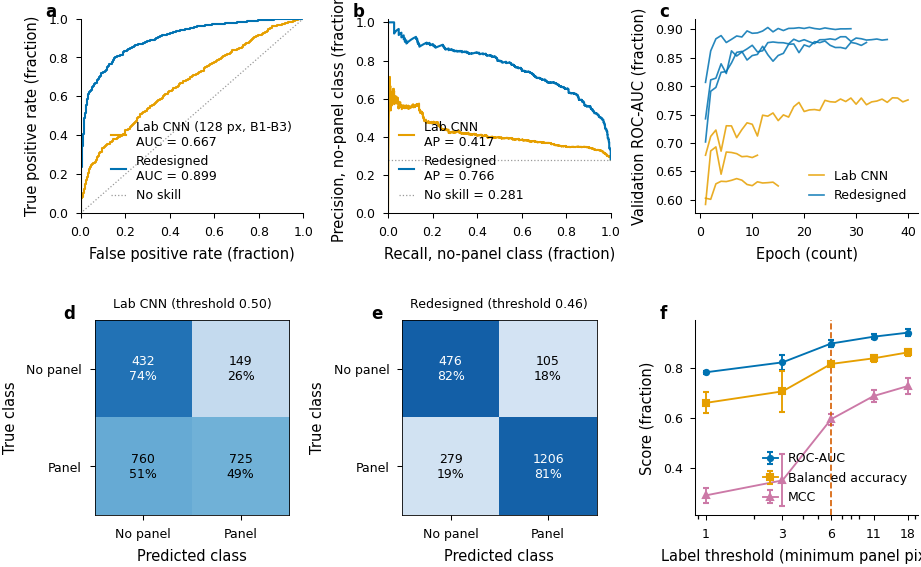

In [27]:
# ---------------------------------------------------------------------------
# Q7.5  Figure 2 -- model performance, to publication standard.
# Curves are pooled across the CV folds (each patch is a test sample exactly once).
# ---------------------------------------------------------------------------
def pool(curves):
    yt = np.concatenate([c[0] for c in curves])
    pp = np.concatenate([c[1] for c in curves])
    return yt, pp

yt_f, pp_f = pool(final_curves)
yt_b, pp_b = pool(base_curves)
thr_f, thr_b = final_res["threshold"][0], base_res["threshold"][0]

fig = plt.figure(figsize=(W_DOUBLE, 4.3))
gs = gridspec.GridSpec(2, 3, hspace=0.55, wspace=0.38, figure=fig)

# ---- (a) ROC ------------------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])
for yt, pp, c, lbl in [(yt_b, pp_b, CB["orange"], "Lab CNN (128 px, B1-B3)"),
                       (yt_f, pp_f, CB["blue"],   "Redesigned")]:
    fpr, tpr, _ = roc_curve(yt, pp)
    ax.plot(fpr, tpr, color=c, label=f"{lbl}\nAUC = {roc_auc_score(yt, pp):.3f}")
ax.plot([0, 1], [0, 1], color=CB["grey"], lw=0.6, ls=":", label="No skill")
ax.set_xlabel("False positive rate (fraction)"); ax.set_ylabel("True positive rate (fraction)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="lower right", handlelength=1.2)
panel_label(ax, "a")

# ---- (b) PR for the MINORITY (no-panel) class ---------------------------------
ax = fig.add_subplot(gs[0, 1])
ns = 1 - yt_f.mean()
for yt, pp, c, lbl in [(yt_b, pp_b, CB["orange"], "Lab CNN"), (yt_f, pp_f, CB["blue"], "Redesigned")]:
    pr, rc, _ = precision_recall_curve(1 - yt, 1 - pp)
    ax.plot(rc, pr, color=c, label=f"{lbl}\nAP = {average_precision_score(1-yt, 1-pp):.3f}")
ax.axhline(ns, color=CB["grey"], lw=0.6, ls=":", label=f"No skill = {ns:.3f}")
ax.set_xlabel("Recall, no-panel class (fraction)"); ax.set_ylabel("Precision, no-panel class (fraction)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc="lower left", handlelength=1.2)
panel_label(ax, "b")

# ---- (c) validation AUC during training ---------------------------------------
ax = fig.add_subplot(gs[0, 2])
for hists, c, lbl in [(base_hists, CB["orange"], "Lab CNN"), (final_hists, CB["blue"], "Redesigned")]:
    for j, h in enumerate(hists):
        ax.plot(np.arange(1, len(h["val_auc"]) + 1), h["val_auc"], color=c, lw=0.8,
                alpha=0.85, label=lbl if j == 0 else None)
ax.set_xlabel("Epoch (count)"); ax.set_ylabel("Validation ROC-AUC (fraction)")
ax.legend(loc="lower right", handlelength=1.2)
panel_label(ax, "c")

# ---- (d, e) confusion matrices -------------------------------------------------
for k, (yt, pp, thr, ttl, letter) in enumerate([
        (yt_b, pp_b, thr_b, "Lab CNN", "d"), (yt_f, pp_f, thr_f, "Redesigned", "e")]):
    ax = fig.add_subplot(gs[1, k])
    cm = confusion_matrix(yt, (pp >= thr).astype(int), labels=[0, 1])
    cmn = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for r in range(2):
        for c_ in range(2):
            ax.text(c_, r, f"{cm[r, c_]}\n{100*cmn[r, c_]:.0f}%", ha="center", va="center",
                    fontsize=6, color="white" if cmn[r, c_] > 0.55 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No panel", "Panel"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["No panel", "Panel"])
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    ax.set_title(f"{ttl} (threshold {thr:.2f})", fontsize=6)
    for s in ax.spines.values(): s.set_visible(True); s.set_linewidth(0.4)
    panel_label(ax, letter)

# ---- (f) threshold sweep --------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
ts = list(sweep.keys())
for key, c, mk, lbl in [("roc_auc", CB["blue"], "o", "ROC-AUC"),
                        ("balanced_acc", CB["orange"], "s", "Balanced accuracy"),
                        ("mcc", CB["purple"], "^", "MCC")]:
    mu_ = [sweep[t][key][0] for t in ts]; sd_ = [sweep[t][key][1] for t in ts]
    ax.errorbar(ts, mu_, yerr=sd_, color=c, marker=mk, ms=2.5, lw=0.9, capsize=1.5, label=lbl)
ax.axvline(T_HEADLINE, color=CB["vermilion"], lw=0.8, ls="--")
ax.set_xscale("log"); ax.set_xticks(ts); ax.set_xticklabels([str(t) for t in ts])
ax.set_xlabel("Label threshold (minimum panel pixels)"); ax.set_ylabel("Score (fraction)")
ax.legend(loc="lower right", handlelength=1.2)
panel_label(ax, "f")

save_figure(fig, "fig2_model_performance")
plt.show()